# 🔍 Model Validation (Is 100% Real?)
## Three rigorous tests to confirm the model is truly robust
---
**Why this matters:** 100% accuracy can sometimes be too good to be true.
Ran 3 validation tests before trusting the model for real-time deployment:

1. **Temporal Split** — Train on first 80% of data, test on last 20% (not random)
2. **Without distance_m** — Test if model works without the #1 feature
3. **Minimal Features** — Test with only the top 5 features

If all 3 pass with >95%, the model is genuinely robust.

## Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q xgboost lightgbm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, gc, csv, os, warnings, pickle
from scipy import stats as sp_stats
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
print('✅ Libraries loaded!')

Mounted at /content/drive
✅ Libraries loaded!


## Cell 2 — Load Data & Extract Features

In [ ]:
BASE_DIR = '/content/drive/MyDrive/VER Machine Learning Data'

FILE_PATHS = {
    'human':   os.path.join(BASE_DIR, 'signal_human2.csv'),
    'chair':   os.path.join(BASE_DIR, 'signal_chair.csv'),
    'nothing': os.path.join(BASE_DIR, 'signal_nothing.csv'),
}

N_METADATA_COLS = 17
N_SIGNAL_SAMPLES = 25000
SAMPLING_RATE = 1_953_125

def count_rows(filepath):
    with open(filepath, 'r') as f:
        return sum(1 for _ in f)

def load_csv_efficient(filepath, label, dtype=np.float32):
    n_rows = count_rows(filepath)
    print(f'  {n_rows} rows', end=' → ')
    metadata = np.empty((n_rows, N_METADATA_COLS), dtype=dtype)
    signal = np.empty((n_rows, N_SIGNAL_SAMPLES), dtype=dtype)
    chunk_size = 100
    row_idx = 0
    with open(filepath, 'r') as f:
        reader = csv.reader(f)
        batch_rows = []
        for i, row in enumerate(reader):
            batch_rows.append(row)
            if len(batch_rows) == chunk_size:
                arr = np.array(batch_rows, dtype=dtype)
                n = arr.shape[0]
                metadata[row_idx:row_idx+n, :] = arr[:, :N_METADATA_COLS]
                signal[row_idx:row_idx+n, :] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
                row_idx += n
                batch_rows = []
        if batch_rows:
            arr = np.array(batch_rows, dtype=dtype)
            n = arr.shape[0]
            metadata[row_idx:row_idx+n, :] = arr[:, :N_METADATA_COLS]
            signal[row_idx:row_idx+n, :] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
            row_idx += n
    print(f'Loaded {row_idx} rows.')
    return metadata[:row_idx], signal[:row_idx]

data = {}
for label, path in FILE_PATHS.items():
    print(f'📂 {label.upper()}:', end='')
    meta, sig = load_csv_efficient(path, label)
    data[label] = {'metadata': meta, 'signal': sig}
    gc.collect()

print('\n✅ Data loaded!')

📂 HUMAN:  5005 rows → Loaded 5005 rows.
📂 CHAIR:  5000 rows → Loaded 5000 rows.
📂 NOTHING:  5002 rows → Loaded 5002 rows.

✅ Data loaded!


## Cell 3 — Feature Extraction

In [ ]:
def extract_features(signal, metadata):
    features = {}
    N_WINDOWS = 25
    WINDOW_SIZE = 1000
    sig_windowed = signal[:N_WINDOWS * WINDOW_SIZE].reshape(N_WINDOWS, WINDOW_SIZE)
    seg_energy = np.sum(sig_windowed ** 2, axis=1).astype(np.float64)
    total_energy = np.sum(seg_energy) + 1e-10
    seg_energy_norm = seg_energy / total_energy
    for i in range(N_WINDOWS):
        features[f'seg_energy_{i}'] = seg_energy_norm[i]
    features['seg_max_window'] = np.argmax(seg_energy)
    early_end = int(4.0 / 12.8 * N_WINDOWS)
    mid_end = int(8.0 / 12.8 * N_WINDOWS)
    features['energy_early'] = np.sum(seg_energy_norm[:early_end])
    features['energy_mid'] = np.sum(seg_energy_norm[early_end:mid_end])
    features['energy_late'] = np.sum(seg_energy_norm[mid_end:])
    sig_f64 = signal.astype(np.float64)
    abs_sig = np.abs(sig_f64)
    features['rms'] = np.sqrt(np.mean(sig_f64 ** 2))
    features['std'] = np.std(sig_f64)
    features['peak_amplitude'] = np.max(abs_sig)
    features['peak_positive'] = np.max(sig_f64)
    features['peak_negative'] = np.min(sig_f64)
    features['mean_amplitude'] = np.mean(sig_f64)
    features['mean_abs'] = np.mean(abs_sig)
    features['crest_factor'] = features['peak_amplitude'] / (features['rms'] + 1e-10)
    peak_idx = np.argmax(abs_sig)
    features['peak_time_ms'] = peak_idx / SAMPLING_RATE * 1000
    window_smooth = 500
    envelope = np.convolve(abs_sig, np.ones(window_smooth)/window_smooth, mode='same')
    threshold = np.mean(envelope) + 2 * np.std(envelope)
    peaks, properties = find_peaks(envelope, height=threshold, distance=1000)
    features['n_peaks'] = len(peaks)
    if len(peaks) > 0:
        features['first_peak_time_ms'] = peaks[0] / SAMPLING_RATE * 1000
        features['last_peak_time_ms'] = peaks[-1] / SAMPLING_RATE * 1000
        features['peak_spread_ms'] = features['last_peak_time_ms'] - features['first_peak_time_ms']
    else:
        features['first_peak_time_ms'] = 0
        features['last_peak_time_ms'] = 0
        features['peak_spread_ms'] = 0
    features['skewness'] = float(sp_stats.skew(sig_f64))
    features['kurtosis'] = float(sp_stats.kurtosis(sig_f64))
    zero_crossings = np.sum(np.diff(np.sign(sig_f64)) != 0)
    features['zero_crossing_rate'] = zero_crossings / len(sig_f64)
    fft_vals = np.fft.rfft(sig_f64)
    fft_magnitude = np.abs(fft_vals)
    fft_freqs = np.fft.rfftfreq(len(sig_f64), d=1.0/SAMPLING_RATE)
    features['spectral_energy'] = np.sum(fft_magnitude ** 2)
    features['dominant_freq_hz'] = fft_freqs[np.argmax(fft_magnitude[1:]) + 1]
    spectral_sum = np.sum(fft_magnitude) + 1e-10
    features['spectral_centroid'] = np.sum(fft_freqs * fft_magnitude) / spectral_sum
    features['spectral_bandwidth'] = np.sqrt(
        np.sum(((fft_freqs - features['spectral_centroid']) ** 2) * fft_magnitude) / spectral_sum
    )
    band_mask = (fft_freqs >= 35000) & (fft_freqs <= 45000)
    features['energy_40khz_band'] = np.sum(fft_magnitude[band_mask] ** 2)
    features['distance_m'] = metadata[10]
    features['energy_metric'] = metadata[16]
    return features

print('✅ Feature function ready!')

✅ Feature function ready!


## Cell 4 — Extract Features (preserving order per class)

In [ ]:
# Extract features FOR EACH CLASS SEPARATELY (preserving temporal order)
label_map = {'human': 0, 'chair': 1, 'nothing': 2}
label_names = ['Human', 'Chair', 'Nothing']

features_per_class = {}

for label in ['human', 'chair', 'nothing']:
    sig = data[label]['signal']
    meta = data[label]['metadata']
    n = sig.shape[0]

    print(f'\n🔧 Extracting features for {label.upper()} ({n} samples)...')
    t0 = time.time()

    feats = []
    for i in range(n):
        feats.append(extract_features(sig[i], meta[i]))
        if (i + 1) % 1000 == 0:
            print(f'    {i+1}/{n}...')

    features_per_class[label] = pd.DataFrame(feats)
    print(f'  ✅ Done in {time.time()-t0:.1f}s')

# Free raw data
del data
gc.collect()

# Clean
for label in features_per_class:
    features_per_class[label] = features_per_class[label].fillna(0)
    features_per_class[label] = features_per_class[label].replace([np.inf, -np.inf], 0)

print(f'\n✅ Features extracted and cleaned for all classes!')


🔧 Extracting features for HUMAN (5005 samples)...
    1000/5005...
    2000/5005...
    3000/5005...
    4000/5005...
    5000/5005...
  ✅ Done in 30.1s

🔧 Extracting features for CHAIR (5000 samples)...
    1000/5000...
    2000/5000...
    3000/5000...
    4000/5000...
    5000/5000...
  ✅ Done in 30.7s

🔧 Extracting features for NOTHING (5002 samples)...
    1000/5002...
    2000/5002...
    3000/5002...
    4000/5002...
    5000/5002...
  ✅ Done in 30.3s

✅ Features extracted and cleaned for all classes!


## Cell 5 — 🧪 TEST 1: Temporal Split (Train on first 80%, Test on last 20%)

  TEST 1: TEMPORAL SPLIT (First 80% → Train, Last 20% → Test)
  This simulates real deployment: train on old data, test on new.

  HUMAN   : Train=4004, Test=1001
  CHAIR   : Train=4000, Test=1000
  NOTHING : Train=4001, Test=1001

  Total Train: 12005, Test: 3002

  Results (Temporal Split):
    Random Forest       : 99.47%
    XGBoost             : 99.27%
    LightGBM            : 99.57%


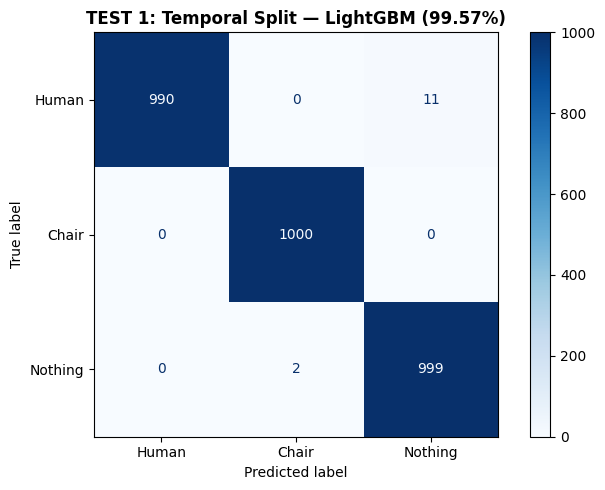


  Classification Report (LightGBM):
              precision    recall  f1-score   support

       Human       1.00      0.99      0.99      1001
       Chair       1.00      1.00      1.00      1000
     Nothing       0.99      1.00      0.99      1001

    accuracy                           1.00      3002
   macro avg       1.00      1.00      1.00      3002
weighted avg       1.00      1.00      1.00      3002



In [ ]:
print('='*65)
print('  TEST 1: TEMPORAL SPLIT (First 80% → Train, Last 20% → Test)')
print('='*65)

SPLIT_RATIO = 0.8

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []

for label in ['human', 'chair', 'nothing']:
    df = features_per_class[label]
    n = len(df)
    split_idx = int(n * SPLIT_RATIO)

    X_train_list.append(df.iloc[:split_idx].values)
    X_test_list.append(df.iloc[split_idx:].values)
    y_train_list.append(np.full(split_idx, label_map[label]))
    y_test_list.append(np.full(n - split_idx, label_map[label]))

    print(f'  {label.upper():8s}: Train={split_idx}, Test={n-split_idx}')

X_train_t = np.vstack(X_train_list)
X_test_t = np.vstack(X_test_list)
y_train_t = np.concatenate(y_train_list)
y_test_t = np.concatenate(y_test_list)

print(f'\n  Total Train: {len(y_train_t)}, Test: {len(y_test_t)}')

# Train models
test1_models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
}

print(f'\n  Results (Temporal Split):')
test1_results = {}
for name, model in test1_models.items():
    model.fit(X_train_t, y_train_t)
    y_pred = model.predict(X_test_t)
    acc = accuracy_score(y_test_t, y_pred)
    test1_results[name] = acc
    print(f'    {name:<20s}: {acc*100:.2f}%')

# Confusion matrix for best
best_t1_name = max(test1_results, key=test1_results.get)
best_t1_model = test1_models[best_t1_name]
y_pred_t1 = best_t1_model.predict(X_test_t)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
cm = confusion_matrix(y_test_t, y_pred_t1)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'TEST 1: Temporal Split — {best_t1_name} ({test1_results[best_t1_name]*100:.2f}%)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/content/validation_test1_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class report
print(f'\n  Classification Report ({best_t1_name}):')
print(classification_report(y_test_t, y_pred_t1, target_names=label_names))

## Cell 6 — 🧪 TEST 2: Without distance_m Feature
Tests if the model can still classify without the #1 most important feature.

  TEST 2: WITHOUT distance_m (Temporal Split)
  Removing distance_m to test if signal features alone are enough.

  Removed: ['distance_m', 'energy_metric']
  Remaining features: 50

  Results (No distance_m, Temporal Split):
    Random Forest       : 99.00%
    XGBoost             : 99.17%
    LightGBM            : 99.53%


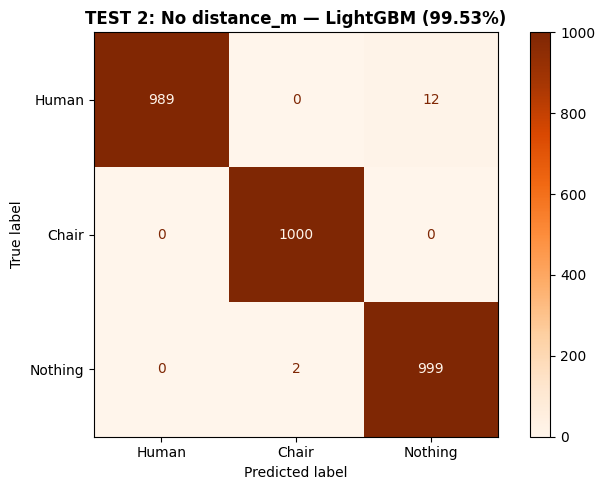


  Classification Report (LightGBM):
              precision    recall  f1-score   support

       Human       1.00      0.99      0.99      1001
       Chair       1.00      1.00      1.00      1000
     Nothing       0.99      1.00      0.99      1001

    accuracy                           1.00      3002
   macro avg       1.00      1.00      1.00      3002
weighted avg       1.00      1.00      1.00      3002



In [ ]:
print('='*65)
print('  TEST 2: WITHOUT distance_m (Temporal Split)')
print('='*65)
print('  Removing distance_m to test if signal features alone are enough.\n')

# Get feature names and find distance_m and energy_metric columns
feature_names = features_per_class['human'].columns.tolist()

# Remove metadata-based features
drop_cols = ['distance_m', 'energy_metric']
keep_cols = [i for i, name in enumerate(feature_names) if name not in drop_cols]
keep_names = [feature_names[i] for i in keep_cols]

print(f'  Removed: {drop_cols}')
print(f'  Remaining features: {len(keep_cols)}\n')

X_train_t2 = X_train_t[:, keep_cols]
X_test_t2 = X_test_t[:, keep_cols]

test2_models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
}

print(f'  Results (No distance_m, Temporal Split):')
test2_results = {}
for name, model in test2_models.items():
    model.fit(X_train_t2, y_train_t)
    y_pred = model.predict(X_test_t2)
    acc = accuracy_score(y_test_t, y_pred)
    test2_results[name] = acc
    print(f'    {name:<20s}: {acc*100:.2f}%')

# Confusion matrix
best_t2_name = max(test2_results, key=test2_results.get)
y_pred_t2 = test2_models[best_t2_name].predict(X_test_t2)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
cm = confusion_matrix(y_test_t, y_pred_t2)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title(f'TEST 2: No distance_m — {best_t2_name} ({test2_results[best_t2_name]*100:.2f}%)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/content/validation_test2_no_distance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n  Classification Report ({best_t2_name}):')
print(classification_report(y_test_t, y_pred_t2, target_names=label_names))

## Cell 7 — 🧪 TEST 3: Minimal Features Only (Top 5)
Can we classify with just 5 features? This would be fastest for real-time.

  TEST 3: TOP 5 FEATURES ONLY (Temporal Split)
  Top 5 features: ['seg_energy_15', 'crest_factor', 'peak_amplitude', 'peak_positive', 'peak_negative']

  Results (Top 5 Features, Temporal Split):
    Random Forest       : 95.17%
    XGBoost             : 95.10%
    LightGBM            : 95.24%


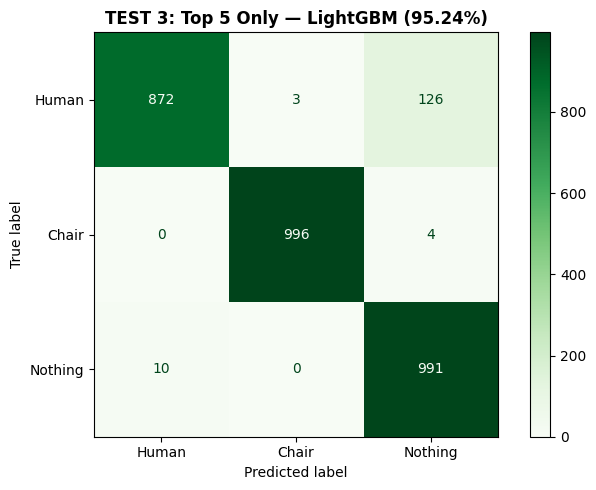


  Classification Report (LightGBM):
              precision    recall  f1-score   support

       Human       0.99      0.87      0.93      1001
       Chair       1.00      1.00      1.00      1000
     Nothing       0.88      0.99      0.93      1001

    accuracy                           0.95      3002
   macro avg       0.96      0.95      0.95      3002
weighted avg       0.96      0.95      0.95      3002



In [ ]:
print('='*65)
print('  TEST 3: TOP 5 FEATURES ONLY (Temporal Split)')
print('='*65)

# Train a RF on full features to get importance ranking (on temporal train set)
rf_full = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_full.fit(X_train_t, y_train_t)
importances = rf_full.feature_importances_

# Get top 5 features (excluding distance_m)
sorted_idx = np.argsort(importances)[::-1]
top5_idx = sorted_idx[:5]
top5_names = [feature_names[i] for i in top5_idx]

print(f'  Top 5 features: {top5_names}\n')

X_train_t3 = X_train_t[:, top5_idx]
X_test_t3 = X_test_t[:, top5_idx]

test3_models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
}

print(f'  Results (Top 5 Features, Temporal Split):')
test3_results = {}
for name, model in test3_models.items():
    model.fit(X_train_t3, y_train_t)
    y_pred = model.predict(X_test_t3)
    acc = accuracy_score(y_test_t, y_pred)
    test3_results[name] = acc
    print(f'    {name:<20s}: {acc*100:.2f}%')

# Confusion matrix
best_t3_name = max(test3_results, key=test3_results.get)
y_pred_t3 = test3_models[best_t3_name].predict(X_test_t3)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
cm = confusion_matrix(y_test_t, y_pred_t3)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title(f'TEST 3: Top 5 Only — {best_t3_name} ({test3_results[best_t3_name]*100:.2f}%)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/content/validation_test3_top5.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n  Classification Report ({best_t3_name}):')
print(classification_report(y_test_t, y_pred_t3, target_names=label_names))

## Cell 8 — 📊 VALIDATION SUMMARY

In [ ]:
print('='*65)
print('        VALIDATION SUMMARY REPORT')
print('='*65)

print(f'\n  TEST 1 — Temporal Split (all features):')
for name, acc in sorted(test1_results.items(), key=lambda x: x[1], reverse=True):
    status = '✅' if acc >= 0.95 else '⚠️'
    print(f'    {status} {name:<20s}: {acc*100:.2f}%')

print(f'\n  TEST 2 — No distance_m (temporal split):')
for name, acc in sorted(test2_results.items(), key=lambda x: x[1], reverse=True):
    status = '✅' if acc >= 0.95 else '⚠️'
    print(f'    {status} {name:<20s}: {acc*100:.2f}%')

print(f'\n  TEST 3 — Top 5 features only (temporal split):')
for name, acc in sorted(test3_results.items(), key=lambda x: x[1], reverse=True):
    status = '✅' if acc >= 0.95 else '⚠️'
    print(f'    {status} {name:<20s}: {acc*100:.2f}%')

# Overall verdict
all_pass = (
    max(test1_results.values()) >= 0.95 and
    max(test2_results.values()) >= 0.95 and
    max(test3_results.values()) >= 0.95
)

print(f'\n{"="*65}')
if all_pass:
    print('  ✅ ALL 3 TESTS PASSED! Model is genuinely robust.')
    print('  → The model works with temporal split, without distance_m,')
    print('    and even with just 5 features. Ready for deployment!')
else:
    print('  ⚠️  SOME TESTS DID NOT PASS ≥95%')
print('='*65)

        VALIDATION SUMMARY REPORT

  TEST 1 — Temporal Split (all features):
    ✅ LightGBM            : 99.57%
    ✅ Random Forest       : 99.47%
    ✅ XGBoost             : 99.27%

  TEST 2 — No distance_m (temporal split):
    ✅ LightGBM            : 99.53%
    ✅ XGBoost             : 99.17%
    ✅ Random Forest       : 99.00%

  TEST 3 — Top 5 features only (temporal split):
    ✅ LightGBM            : 95.24%
    ✅ Random Forest       : 95.17%
    ✅ XGBoost             : 95.10%

  ✅ ALL 3 TESTS PASSED! Model is genuinely robust.
  → The model works with temporal split, without distance_m,
    and even with just 5 features. Ready for deployment!

Please copy this entire output and share it back!
